#### 多因子房价预测




In [1]:
# 加载数据
import pandas as pd
import numpy as np

from StageOne.ML.Week_2.LR_generated_data import y_predict

data = pd.read_csv("usa_housing_price.csv")
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Area Population,size,Price
0,79545.45857,5.317139,7.009188,23086.80050,188.214212,1.059034e+06
1,79248.64245,4.997100,6.730821,40173.07217,160.042526,1.505891e+06
2,61287.06718,5.134110,8.512727,36882.15940,227.273545,1.058988e+06
3,63345.24005,3.811764,5.586729,34310.24283,164.816630,1.260617e+06
4,59982.19723,5.959445,7.839388,26354.10947,161.966659,6.309435e+05


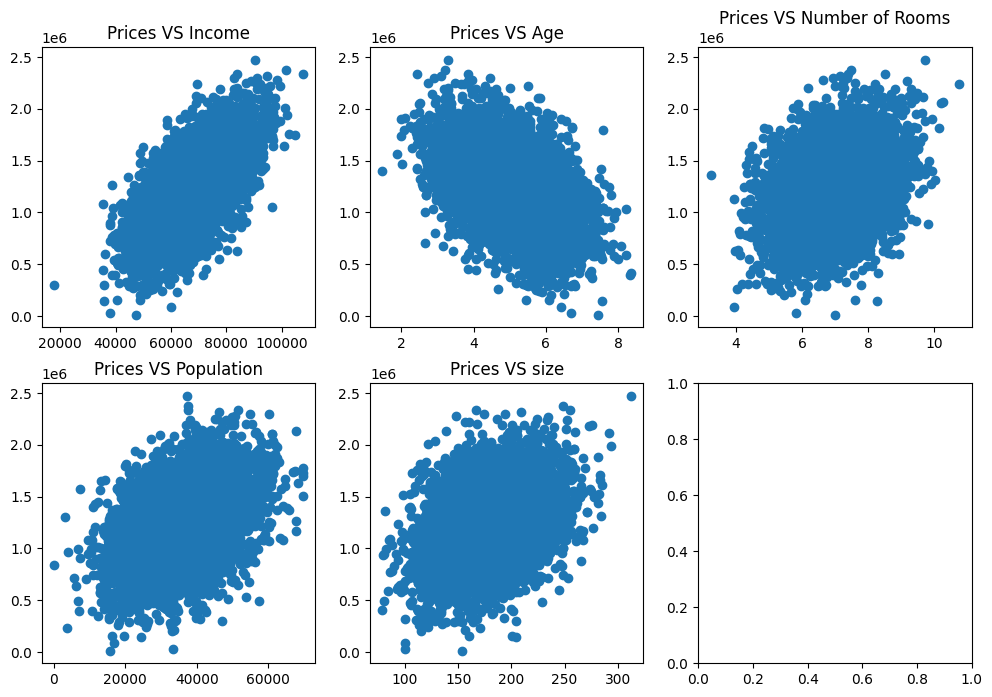

In [6]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(12,8))
fig1 = plt.subplot(231)
plt.scatter(data.loc[:,'Avg. Area Income'],data.loc[:,'Price'])
plt.title('Prices VS Income')

fig2 = plt.subplot(232)
plt.scatter(data.loc[:,'Avg. Area House Age'],data.loc[:,'Price'])
plt.title('Prices VS Age')

fig3 = plt.subplot(233)
plt.scatter(data.loc[:,'Avg. Area Number of Rooms'],data.loc[:,'Price'])
plt.title('Prices VS Number of Rooms')

fig4 = plt.subplot(234)
plt.scatter(data.loc[:,'Area Population'],data.loc[:,'Price'])
plt.title('Prices VS Population')

fig5 = plt.subplot(235)
plt.scatter(data.loc[:,'size'],data.loc[:,'Price'])
plt.title('Prices VS size')
fig6 = plt.subplot(236)

plt.show()

In [7]:
# 单一因素，尺寸价格
X = data.loc[:,'size']
y = data.loc[:,'Price']
y.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

In [11]:
X = np.array(X).reshape(-1,1)
y = np.array(y).reshape(-1,1)
print(X.shape)

(5000, 1)


In [12]:
from sklearn.linear_model import LinearRegression
LR1 = LinearRegression()
LR1.fit(X,y)

LinearRegression()

In [14]:
y_predict_1 = LR1.predict(X)
print(y_predict_1)

[[1276881.85636623]
 [1173363.58767144]
 [1420407.32457443]
 ...
 [1097848.86467426]
 [1264502.88144558]
 [1131278.58816273]]


In [15]:
from sklearn.metrics import r2_score,mean_squared_error
mean_squared_error_1 = mean_squared_error(y,y_predict_1)
r2_score_1 = r2_score(y,y_predict_1)
print(mean_squared_error_1,r2_score_1)

108771672553.6264 0.1275031240418234


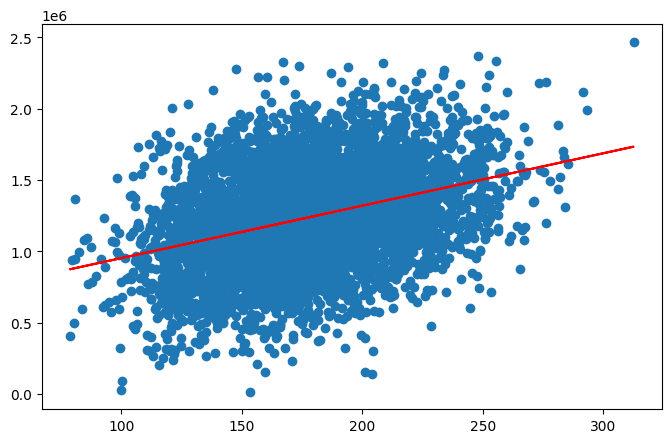

In [16]:
fig6 = plt.figure(figsize=(8,5))
plt.scatter(X,y)
plt.plot(X,y_predict_1,'r')

In [17]:
X_mulit = data.drop(['Price'],axis=1)
X_mulit

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Area Population,size
0,79545.45857,5.317139,7.009188,23086.80050,188.214212
1,79248.64245,4.997100,6.730821,40173.07217,160.042526
2,61287.06718,5.134110,8.512727,36882.15940,227.273545
3,63345.24005,3.811764,5.586729,34310.24283,164.816630
4,59982.19723,5.959445,7.839388,26354.10947,161.966659
...,...,...,...,...,...
4995,60567.94414,3.169638,6.137356,22837.36103,161.641403
4996,78491.27543,4.000865,6.576763,25616.11549,159.164596
4997,63390.68689,3.749409,4.805081,33266.14549,139.491785
4998,68001.33124,5.465612,7.130144,42625.62016,184.845371


In [19]:
LR_multi = LinearRegression()
LR_multi.fit(X_mulit,y)

LinearRegression()

In [20]:
y_predict_multi = LR_multi.predict(X_mulit)
print(y_predict_multi)

[[1223968.89166086]
 [1497306.3318863 ]
 [1250884.31019437]
 ...
 [1020693.92390376]
 [1260503.36914585]
 [1302737.7915763 ]]


In [21]:
mean_squared_error_multi = mean_squared_error(y,y_predict_multi)
r2_score_multi = r2_score(y,y_predict_multi)
print(mean_squared_error_multi,r2_score_multi)

10219846512.17786 0.9180229195220739


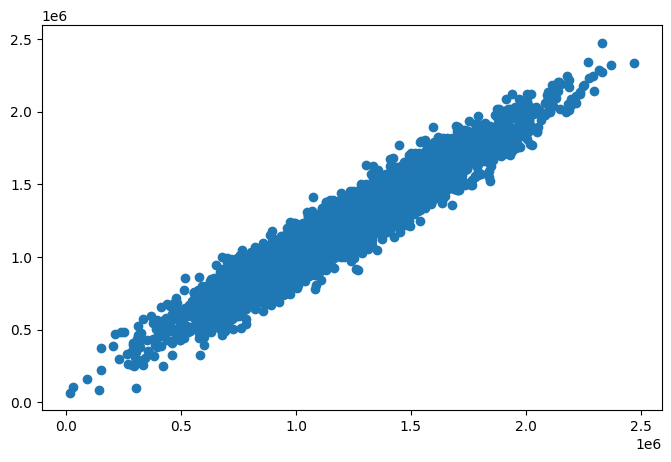

In [22]:
fig7 = plt.figure(figsize=(8,5))
plt.scatter(y,y_predict_multi)
plt.show()

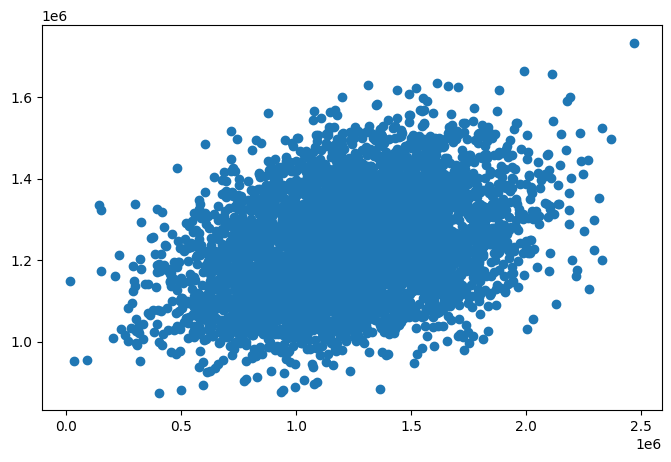

In [23]:
fig7 = plt.figure(figsize=(8,5))
plt.scatter(y,y_predict_1)
plt.show()

In [28]:
X_test = [65000,5,5,30000,200]
X_test = np.array(X_test).reshape(1,-1)
print(X_test.shape)

(1, 5)


In [31]:
y_test_predict = LR_multi.predict(X_test)
print(y_test_predict)

[[817052.19516298]]


D:\Study\Python\Daily_work\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


上面预测试会跟一个warning，是因为在训练数据的时候用的是pandas的数据类型，特征是带名字的，但是预测是使用的numpy的数组，不带属性名的，可以前后一致便可以了